In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/processed/data.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
x=df.drop(columns=["Churn"])
y=df["Churn"]

In [4]:
le=LabelEncoder()
y=le.fit_transform(y)

In [5]:
numerical_cols=x.select_dtypes(include=["int64", "float64"]).columns
categorical_cols=x.select_dtypes(include=["object", "string"]).columns
print(numerical_cols)
print(categorical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [6]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_cols)
    ]
)

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [8]:
results=[]

In [9]:
def evaluate_classifier(pipeline, model_name):

    start = time.time()
    pipeline.fit(x_train, y_train)
    training_time = time.time() - start
    y_pred = pipeline.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Training Time (s)": training_time
    })

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"ROC-AUC       : {roc_auc:.4f}")
    print(f"Training Time : {training_time:.4f} sec")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

Logistic Regression
Accuracy      : 0.8067
Precision     : 0.6361
Recall        : 0.5762
F1 Score      : 0.6047
ROC-AUC       : 0.7312
Training Time : 0.0396 sec

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1046
           1       0.64      0.58      0.60       361

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



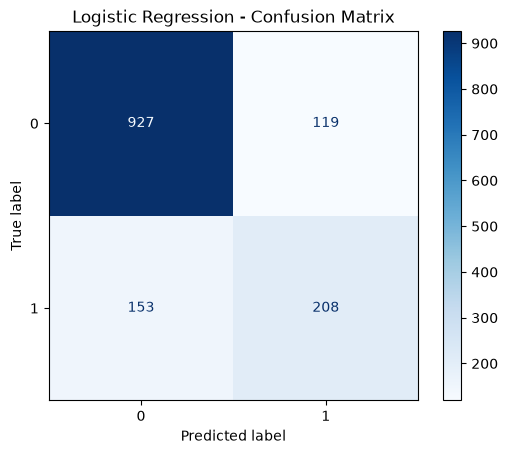

Logistic Regression model saved successfully!


In [10]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

evaluate_classifier(
    logistic_pipeline,
    "Logistic Regression"
)

import joblib

joblib.dump(
    logistic_pipeline,
    "../models/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully!")

K-Nearest Neighbors
Accuracy      : 0.7669
Precision     : 0.5422
Recall        : 0.5873
F1 Score      : 0.5638
ROC-AUC       : 0.7081
Training Time : 0.0253 sec

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1046
           1       0.54      0.59      0.56       361

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.77      0.77      1407



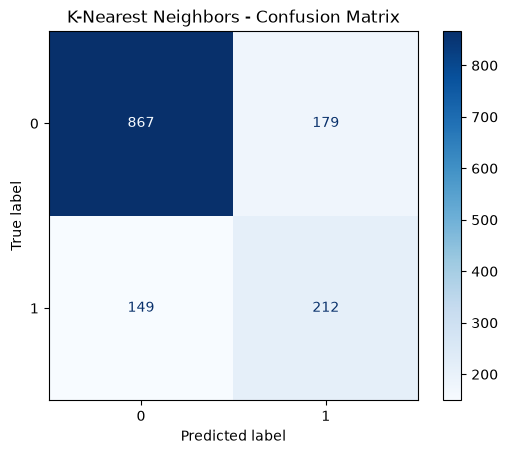

In [11]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

evaluate_classifier(
    knn_pipeline,
    "K-Nearest Neighbors"
)

Decision Tree
Accuracy      : 0.7313
Precision     : 0.4776
Recall        : 0.5014
F1 Score      : 0.4892
ROC-AUC       : 0.6560
Training Time : 0.0375 sec

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1046
           1       0.48      0.50      0.49       361

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.74      0.73      0.73      1407



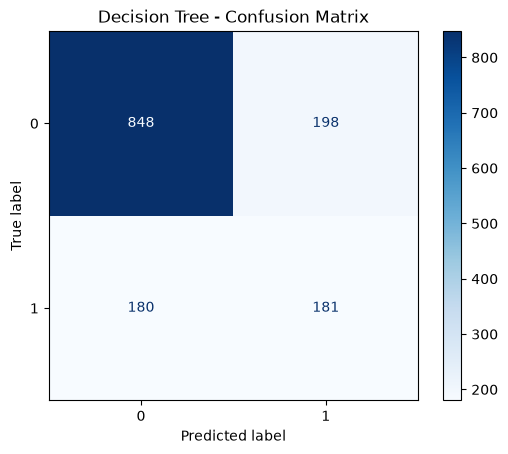

In [12]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

evaluate_classifier(
    dt_pipeline,
    "Decision Tree"
)

Random Forest
Accuracy      : 0.7996
Precision     : 0.6231
Recall        : 0.5540
F1 Score      : 0.5865
ROC-AUC       : 0.7192
Training Time : 0.3931 sec

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1046
           1       0.62      0.55      0.59       361

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



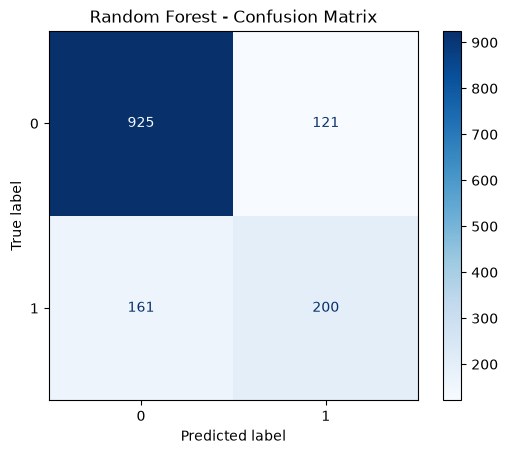

In [13]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

evaluate_classifier(
    rf_pipeline,
    "Random Forest"
)

Support Vector Machine
Accuracy      : 0.8074
Precision     : 0.6596
Recall        : 0.5152
F1 Score      : 0.5785
ROC-AUC       : 0.7117
Training Time : 0.5027 sec

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1046
           1       0.66      0.52      0.58       361

    accuracy                           0.81      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.80      0.81      0.80      1407



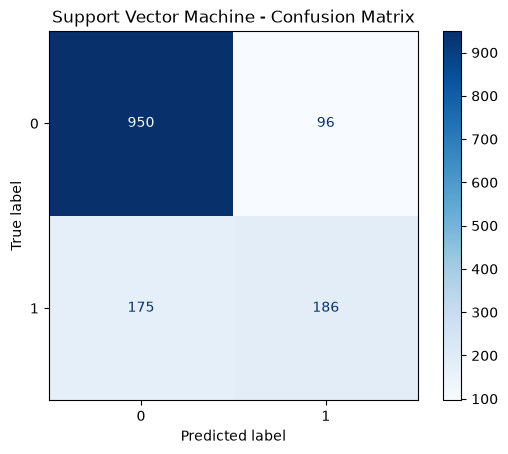

In [14]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

evaluate_classifier(
    svm_pipeline,
    "Support Vector Machine"
)

Naive Bayes
Accuracy      : 0.6489
Precision     : 0.4140
Recall        : 0.8864
F1 Score      : 0.5644
ROC-AUC       : 0.7267
Training Time : 0.0216 sec

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.57      0.71      1046
           1       0.41      0.89      0.56       361

    accuracy                           0.65      1407
   macro avg       0.67      0.73      0.64      1407
weighted avg       0.80      0.65      0.67      1407



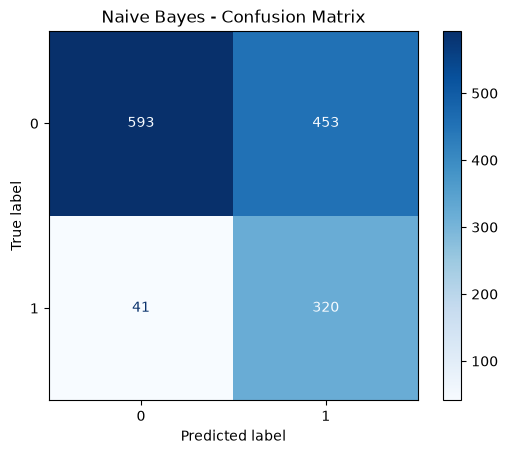

In [15]:
dense_preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False),categorical_cols)
    ]
)

nb_pipeline = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", GaussianNB())
])

evaluate_classifier(
    nb_pipeline,
    "Naive Bayes"
)

In [16]:
results_df = pd.DataFrame(results)
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.806681,0.636086,0.576177,0.604651,0.731205,0.039551
3,Random Forest,0.799574,0.623053,0.554017,0.586510,0.719169,0.393070
4,Support Vector Machine,0.807392,0.659574,0.515235,0.578538,0.711729,0.502731
5,Naive Bayes,0.648898,0.413972,0.886427,0.564374,0.726674,0.021578
1,K-Nearest Neighbors,0.766880,0.542199,0.587258,0.563830,0.708065,0.025256
2,Decision Tree,0.731343,0.477573,0.501385,0.489189,0.656046,0.037452


# **Classification Summary**

- Six classification algorithms were benchmarked for customer churn prediction.

- Models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Training Time.

- Since the objective is to identify customers who are likely to churn, Recall and F1 Score are the most important evaluation metrics.

- The best-performing model will be selected based on its ability to correctly identify churning customers while maintaining a good balance between precision and recall.